**© Copyright AIDENTIFY. All rights reserved.**

본 자료는 **멀티캠퍼스 LLM 파인튜닝 과정** 수강생을 위해 제작되었으며, 강의 목적으로만 사용 가능합니다.  
무단 복제, 배포, 상업적 이용을 금지합니다.

---

# Session 34: 프로젝트 학습 수행

## 🎯 모델 학습 실행

이 노트북에서는 수집/정제한 데이터를 사용하여 **LoRA 기반 파인튜닝**을 수행합니다.

### 학습 파이프라인
```
환경 설정 → 모델 로드 → 데이터 로드 → LoRA 설정 → 학습 → (DPO) → 분석 → 저장
```

### 사전 준비
- `33_project_data_pipeline.ipynb`에서 생성한 `train.json`, `eval.json`
- `project_plan.json`에 저장된 모델 설정

### RTX 4060 (VRAM 7.7GB) 실습 환경 설정
| 파라미터 | 값 | 설명 |
|---------|-----|------|
| base model | Qwen2.5-1.5B-Instruct | 본 실습 유일 대상 모델 |
| 양자화 | **사용 안 함 (FP16)** | RTX 4060에서 NF4 호환 불가 |
| batch_size | 1 | OOM 방지 |
| gradient_accumulation_steps | 8 | 실효 배치 = 8 |
| max_seq_length | 1024 | VRAM 절약 |
| fp16 | True | 베이스 모델 FP16 로드 + LoRA 학습 |
| gradient_checkpointing | True | VRAM 절약 |

In [1]:
# =====================================================
# 📦 라이브러리 임포트
# =====================================================
import torch
import gc
import os
import json
import time
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import LoraConfig, get_peft_model, TaskType
from trl import SFTTrainer, SFTConfig
from datasets import Dataset

print("✅ 라이브러리 임포트 완료")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

def print_gpu_memory(tag=""):
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated() / 1024**3
        total = torch.cuda.get_device_properties(0).total_memory / 1024**3
        print(f"[{tag}] GPU: {allocated:.1f}GB / {total:.1f}GB")


/home/yskim/LLM_Advanced/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ 라이브러리 임포트 완료
GPU: NVIDIA GeForce RTX 2070


In [2]:
# =====================================================
# 📂 프로젝트 계획 + 데이터 로드
# =====================================================
OUTPUT_DIR = "./output/project"

with open(os.path.join(OUTPUT_DIR, "project_plan.json"), "r", encoding="utf-8") as f:
    project_plan = json.load(f)

with open(os.path.join(OUTPUT_DIR, "train_data.json"), "r", encoding="utf-8") as f:
    train_data = json.load(f)

MODEL_NAME = project_plan["model_config"]["base_model"]
print(f"✅ 프로젝트 계획 로드: {project_plan['project_name']}")
print(f"📌 모델: {MODEL_NAME}")
print(f"📌 학습 데이터: {len(train_data)}건")


✅ 프로젝트 계획 로드: AI/ML 기술 Q&A sLLM
📌 모델: Qwen/Qwen2.5-1.5B-Instruct
📌 학습 데이터: 40건


---
## 1️⃣ 환경 설정 및 모델 로드

베이스 모델(Qwen2.5-1.5B-Instruct)을 **FP16**으로 로드합니다.

> ⚠️ **RTX 4060 주의**: NF4 4bit 양자화(`BitsAndBytesConfig(load_in_4bit=True, ...)`)는 본 실습 환경에서 호환 문제가 있어 사용하지 않습니다. 베이스 모델은 FP16으로 로드하고 LoRA 어댑터만 학습합니다.

In [3]:
# =====================================================
# 🤖 모델 로드 (FP16)
# =====================================================
print(f"⏳ 모델 로딩 중: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True,
)

print(f"✅ 모델 로드 완료 (FP16)")
print(f"📌 파라미터: {model.num_parameters():,}")
print_gpu_memory("모델 로드 후")


⏳ 모델 로딩 중: Qwen/Qwen2.5-1.5B-Instruct


`torch_dtype` is deprecated! Use `dtype` instead!


✅ 모델 로드 완료 (FP16)
📌 파라미터: 1,543,714,304
[모델 로드 후] GPU: 2.9GB / 7.8GB


---
## 2️⃣ 데이터 로드

이전 노트북에서 준비한 학습 데이터를 로드합니다.

In [4]:
# =====================================================
# 📝 학습 데이터 포맷팅
# =====================================================
def format_messages(item):
    text = tokenizer.apply_chat_template(
        item["messages"], tokenize=False, add_generation_prompt=False
    )
    return text

formatted_texts = [format_messages(item) for item in train_data]
dataset = Dataset.from_dict({"text": formatted_texts})

print(f"✅ 데이터 포맷팅 완료: {len(dataset)}건")
print(f"\n--- 예시 ---")
print(dataset[0]["text"][:300])


✅ 데이터 포맷팅 완료: 40건

--- 예시 ---
<|im_start|>system
당신은 AI/ML 분야의 전문가입니다. 정확하고 이해하기 쉽게 답변해주세요.<|im_end|>
<|im_start|>user
LLM 환각 문제란 무엇인가요?<|im_end|>
<|im_start|>assistant
LLM(대형 언어 모델) 환각 문제는 모델이 사실과 다르거나 존재하지 않는 정보를 생성하는 현상을 말합니다. 예를 들어, 사용자가 질문했을 때 모델이 근거 없는 정보나 허위 사실을 제공하는 경우가 이에 해당합니다. 이러한 환각 현상은 LLM의 학습 데이터에 포함된 불확실한 정보나 편향, 


In [5]:
# =====================================================
# 📋 학습 전 응답 수집 (Before)
# =====================================================
EVAL_PROMPTS = project_plan["eval_prompts"]

model.eval()
before_responses = []
for prompt in EVAL_PROMPTS:
    messages = [
        {"role": "system", "content": "당신은 AI/ML 분야의 전문가입니다."},
        {"role": "user", "content": prompt}
    ]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=200, do_sample=False)
    response = tokenizer.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    before_responses.append(response)
    print(f"🔹 {prompt[:40]}...")
    print(f"   {response[:100]}")
    print()

print(f"✅ Before 응답 {len(before_responses)}건 수집 완료")


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


🔹 LoRA 파인튜닝이 무엇인지 설명하세요....
   LoRA (Low-Rank Adaptation)는 PyTorch에서 제공하는 TensorFlow와 같은 라이브러리에 대한 대체 프레임워크로, 모델을 훈련할 때 사용됩니다. LoRA

🔹 GPU 메모리가 부족할 때 해결 방법을 알려주세요....
   GPU 메모리를 확보하는 가장 기본적인 방법은 GPU를 더 많은 메모리에 연결하는 것입니다. 이는 일반적으로 GPU의 라우터 또는 메모리 카드로 이루어집니다. 그러나, 이러한 접근

🔹 트랜스포머의 Attention 메커니즘을 쉽게 설명하세요....
   Attention 메커니즘은 인공지능에서 가장 중요한 기법 중 하나로, 특히 자연어 처리(NLP)와 컴퓨터 비전에 널리 사용됩니다. 이 메커니즘이란, 특정 부분의 정보를 강조하거나

🔹 Python에서 리스트와 튜플의 차이점은?...
   Python에서 리스트(LIST)와 튜플(TUPLE)은 매우 유사한 데이터 구조를 가지고 있지만, 몇 가지 중요한 차이점이 있습니다:

1. 접근성:
   - 리스트: 순차적으로 

🔹 다음 문장을 영어로 번역하세요: 오늘 날씨가 좋습니다....
   The weather is nice today.

✅ Before 응답 5건 수집 완료


---
## 3️⃣ LoRA 설정

> 💡 **Hint**: LoRA rank(r)가 높을수록 표현력이 좋지만 메모리를 더 사용합니다. RTX 4060 (VRAM 7.7GB)에서 Qwen2.5-1.5B + FP16 기준으로는 r=16이 안전하며, 여유가 있으면 r=32까지 시도 가능합니다.

In [6]:
# =====================================================
# 🔧 LoRA 설정 및 적용
# =====================================================
lora_config = LoraConfig(
    r=project_plan["model_config"]["lora_r"],
    lora_alpha=project_plan["model_config"]["lora_alpha"],
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)

model.train()
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()
print_gpu_memory("LoRA 적용 후")


trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820
[LoRA 적용 후] GPU: 3.0GB / 7.8GB


---
## 4️⃣ 학습 실행 (SFTTrainer)

### Before: 학습 전 모델 출력 확인
학습 전에 모델의 현재 출력을 확인하여 Before/After 비교를 준비합니다.

In [7]:
# =====================================================
# 🚀 SFTTrainer 설정
# =====================================================
tc = project_plan["training_config"]

sft_config = SFTConfig(
    output_dir=os.path.join(OUTPUT_DIR, "checkpoints"),
    num_train_epochs=tc["num_epochs"],
    per_device_train_batch_size=tc["batch_size"],
    gradient_accumulation_steps=tc["gradient_accumulation"],
    learning_rate=tc["learning_rate"],
    fp16=True,
    max_length=tc["max_length"],
    gradient_checkpointing=True,
    logging_steps=1,
    save_strategy="epoch",
    save_total_limit=2,
    dataset_text_field="text",
    report_to="none",
    lr_scheduler_type="cosine",
    warmup_ratio=0.1,
)

trainer = SFTTrainer(
    model=model,
    args=sft_config,
    train_dataset=dataset,
    processing_class=tokenizer,
)

print("✅ SFTTrainer 초기화 완료")
print(f"📌 에포크: {tc['num_epochs']}, 배치: {tc['batch_size']}, LR: {tc['learning_rate']}")
print_gpu_memory("학습 시작 전")


/usr/bin/ld: cannot find -lcufile: 그런 파일이나 디렉터리가 없습니다
collect2: error: ld returned 1 exit status
Truncating train dataset: 100%|██████████| 40/40 [00:00<00:00, 20037.28 examples/s]
The model is already on multiple devices. Skipping the move to device specified in `args`.


✅ SFTTrainer 초기화 완료
📌 에포크: 15, 배치: 1, LR: 0.0002
[학습 시작 전] GPU: 3.0GB / 7.8GB


In [8]:
# =====================================================
# 🔥 학습 실행
# =====================================================
print("🚀 학습 시작!")
print("="*60)

start_time = time.time()
train_result = trainer.train()
training_time = time.time() - start_time

print("="*60)
print("✅ 학습 완료!")
print(f"📌 Total steps: {train_result.global_step}")
print(f"📌 Training loss: {train_result.training_loss:.4f}")
print(f"📌 학습 시간: {training_time:.1f}초")
print_gpu_memory("학습 완료 후")


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


🚀 학습 시작!


Step,Training Loss
1,1.808500
2,1.741000
3,1.713700
4,1.633600
5,1.616500
6,1.398400
7,1.323800
8,1.145700
9,1.071800
10,1.075500


✅ 학습 완료!
📌 Total steps: 75
📌 Training loss: 0.3990
📌 학습 시간: 211.4초
[학습 완료 후] GPU: 3.1GB / 7.8GB


In [9]:
# =====================================================
# 📊 학습 전후 비교 (Before vs After)
# =====================================================
model.eval()

print("📊 학습 전후 비교")
print("="*60)

after_responses = []
for i, prompt in enumerate(EVAL_PROMPTS):
    messages = [
        {"role": "system", "content": "당신은 AI/ML 분야의 전문가입니다."},
        {"role": "user", "content": prompt}
    ]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=200, do_sample=False)
    after = tokenizer.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    after_responses.append(after)
    
    changed = before_responses[i].strip() != after.strip()
    print(f"\n{'='*60}")
    print(f"🔹 {prompt}")
    print(f"  [Before] {before_responses[i][:150]}")
    print(f"  [After]  {after[:150]}")
    print(f"  {'📌 변화 감지!' if changed else '⚪ 변화 없음'}")


📊 학습 전후 비교

🔹 LoRA 파인튜닝이 무엇인지 설명하세요.
  [Before] LoRA (Low-Rank Adaptation)는 PyTorch에서 제공하는 TensorFlow와 같은 라이브러리에 대한 대체 프레임워크로, 모델을 훈련할 때 사용됩니다. LoRA는 일반적인 모델 훈련과는 달리, 학습된 모델의 일부를 임시적으로 제거하여 새로운 모델을 
  [After]  LoRA(LoRA: Low-Rank Adaptation) 파인튜닝은 대규모 언어 모델과 같은 복잡한 모델을 효율적으로 조정하기 위한 기술입니다. 기존의 파인튜닝 방법은 모든 파라미터를 업데이트하는 반면, LoRA는 모델의 특정 부분에 대해 저차원 행렬을 도입하여 가중치
  📌 변화 감지!

🔹 GPU 메모리가 부족할 때 해결 방법을 알려주세요.
  [Before] GPU 메모리를 확보하는 가장 기본적인 방법은 GPU를 더 많은 메모리에 연결하는 것입니다. 이는 일반적으로 GPU의 라우터 또는 메모리 카드로 이루어집니다. 그러나, 이러한 접근법은 비용이 많이 들 수 있습니다.

다른 방법으로는 GPU를 사용하지 않는 대체 기술을 
  [After]  GPU 메모리가 부족할 때는 우선적으로 모델 양자화를 적용하는 것이 효과적입니다. 양자화는 파라미터의 비트 수를 줄이는 방식으로, 동일한 성능을 유지하면서 메모리 사용량을 크게 줄입니다. 또한, 하이퍼파라미터 조정을 통해 학습률이나 스텝 갱신을 감소시키는 것도 도움이 
  📌 변화 감지!

🔹 트랜스포머의 Attention 메커니즘을 쉽게 설명하세요.
  [Before] Attention 메커니즘은 인공지능에서 가장 중요한 기법 중 하나로, 특히 자연어 처리(NLP)와 컴퓨터 비전에 널리 사용됩니다. 이 메커니즘이란, 특정 부분의 정보를 강조하거나 주목하는 방식을 말합니다.

예를 들어, 한 사람이 "나는 오늘 밤 영화를 보고 싶다"라
  [After]  트랜스포머의 Attention 메커니즘은 입력 데이터의 각 요소 간의 관계를 모델링하는 방법입

---
## 5️⃣ 학습 로그 분석

학습 과정의 loss 변화를 분석합니다.

/tmp/ipykernel_64794/2968693508.py:40: UserWarning: Glyph 45936 (\N{HANGUL SYLLABLE DE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_64794/2968693508.py:40: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_64794/2968693508.py:40: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_64794/2968693508.py:40: UserWarning: Glyph 50630 (\N{HANGUL SYLLABLE EOBS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_64794/2968693508.py:40: UserWarning: Glyph 51020 (\N{HANGUL SYLLABLE EUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_64794/2968693508.py:41: UserWarning: Glyph 45936 (\N{HANGUL SYLLABLE DE}) missing from font(s) DejaVu Sans.
  plt.savefig(f"{OUTPUT_DIR}/training_loss.png", dpi=150, bbox_inches="tight")
/tmp/ipykernel_64794/2968693508.py:41: UserWarning: Glyph 51060 (\N{HANGUL 

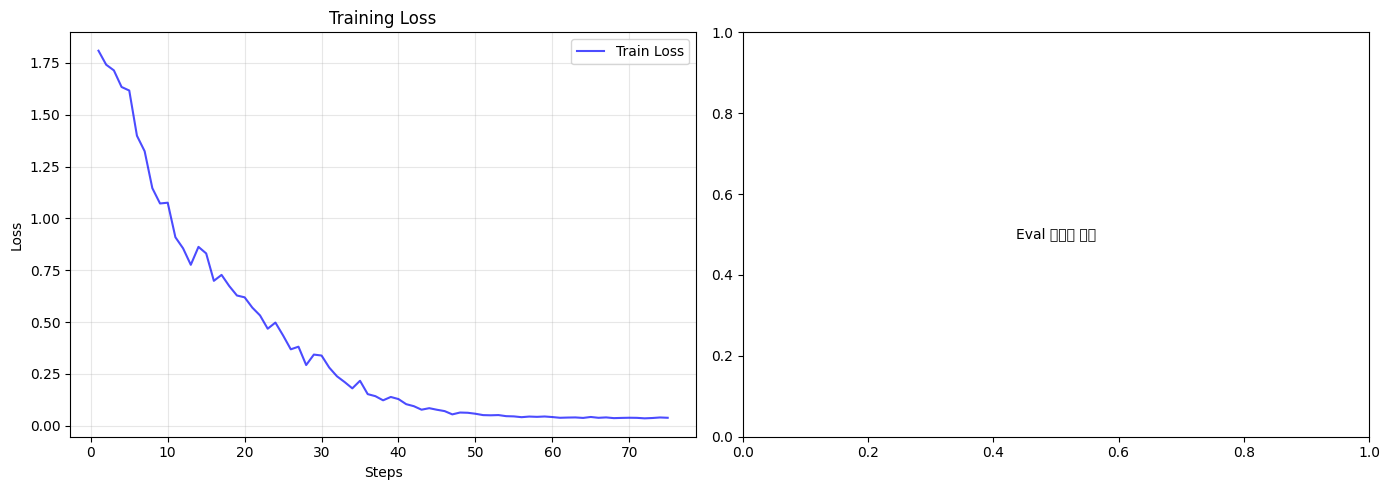


📊 최종 Train Loss: 0.0383


In [10]:
# =====================================================
# 📈 학습 로그 분석
# =====================================================

import matplotlib.pyplot as plt

# 학습 로그 추출
log_history = trainer.state.log_history

# Train loss 추출
train_steps = [log["step"] for log in log_history if "loss" in log]
train_losses = [log["loss"] for log in log_history if "loss" in log]

# Eval loss 추출
eval_steps = [log["step"] for log in log_history if "eval_loss" in log]
eval_losses = [log["eval_loss"] for log in log_history if "eval_loss" in log]

# 그래프 그리기
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train Loss
axes[0].plot(train_steps, train_losses, "b-", alpha=0.7, label="Train Loss")
axes[0].set_xlabel("Steps")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Eval Loss
if eval_losses:
    axes[1].plot(eval_steps, eval_losses, "r-o", alpha=0.7, label="Eval Loss")
    axes[1].set_xlabel("Steps")
    axes[1].set_ylabel("Loss")
    axes[1].set_title("Evaluation Loss")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(0.5, 0.5, "Eval 데이터 없음", ha="center", va="center")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/training_loss.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n📊 최종 Train Loss: {train_losses[-1]:.4f}")
if eval_losses:
    print(f"📊 최종 Eval Loss: {eval_losses[-1]:.4f}")

---
## 6️⃣ 모델 저장

학습된 모델을 저장합니다.

In [11]:
# =====================================================
# 💾 LoRA 어댑터 저장
# =====================================================
save_path = os.path.join(OUTPUT_DIR, "lora_adapter")
model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

total_size = sum(
    os.path.getsize(os.path.join(dp, f))
    for dp, dn, fns in os.walk(save_path)
    for f in fns
)
print(f"✅ 어댑터 저장 완료: {save_path}")
print(f"📌 크기: {total_size / 1024 / 1024:.1f} MB")


✅ 어댑터 저장 완료: ./output/project/lora_adapter
📌 크기: 85.6 MB


In [12]:
# =====================================================
# 🎮 GPU 메모리 정리
# =====================================================

import gc

# 메모리 해제
del trainer
gc.collect()
torch.cuda.empty_cache()

print(f"🎮 GPU 메모리 정리 완료")
print(f"🎮 현재 사용량: {torch.cuda.memory_allocated(0)/1024**3:.2f}GB")

🎮 GPU 메모리 정리 완료
🎮 현재 사용량: 2.96GB


---
## 📝 정리

### 이번 세션에서 완료한 것
- ✅ 모델 로드 (Qwen2.5-1.5B FP16)
- ✅ 학습 데이터 포매팅
- ✅ LoRA 설정 및 학습 실행
- ✅ 학습 로그 분석 (Loss 그래프)
- ✅ Before/After 비교
- ✅ LoRA 어댑터 저장

### 산출물
- 📁 `output/project/lora_adapter/` - LoRA 어댑터
- 📁 `output/project/training_loss.png` - Loss 그래프
- 📁 `output/project/checkpoints/` - 학습 체크포인트

### 하이퍼파라미터 튜닝 가이드 (RTX 4060 기준)
| 증상 | 해결 방법 |
|------|----------|
| Train loss 안 줄어듦 | learning_rate 올리기 (5e-4), 에포크 늘리기 |
| Eval loss 올라감 (오버피팅) | 에포크 줄이기, dropout 올리기, 데이터 늘리기 |
| OOM 에러 | max_seq_length=512로 축소, gradient_checkpointing 확인, LoRA r=8로 축소 |
| 품질이 낮음 | 데이터 품질 확인, 데이터 양 확대, 에포크 증가 |

> ⚠️ **OOM이 계속 발생하면**: 본 환경(Qwen2.5-1.5B + FP16 + LoRA)이 RTX 4060의 한계치이므로, batch_size를 늘리거나 LoRA target_modules를 더 추가하는 것은 피하세요.

### 다음 노트북
👉 **35_project_evaluation.ipynb**: 프로젝트 성능 평가 및 반복 개선